In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Import data

In [ ]:
df = pd.read_csv("dataset.csv")
df

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.698,0.699,0.700,0.701,0.702,0.703,0.704,0.705,0.706,0.707
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
145,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
146,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
147,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


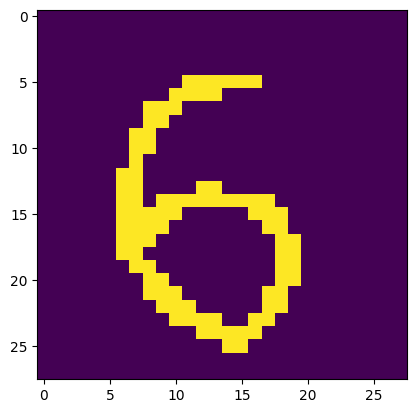

In [ ]:
plt.imshow(df.iloc[95,1:].values.reshape(28,28))

In [ ]:
df.iloc[5,1:].value_counts()

,count
5,
0,684
1,100


#Train test split

In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=35)

#PCA

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 65)

In [ ]:
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

#Model Training

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
Knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
Knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
import time
start = time.time()
y_pred = Knn.predict(X_test)
print(time.time() - start)
y_pred

0.0028128623962402344


array([7, 5, 1, 7, 6, 4, 9, 1, 7, 1, 9, 6, 7, 5, 8, 5, 0, 4, 2, 8, 5, 3,
       1, 8, 0, 6, 2, 0, 4, 3])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

86.66666666666667

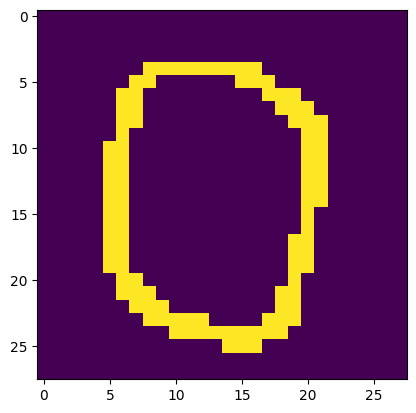

In [ ]:
plt.imshow(df.iloc[3,1:].values.reshape(28,28))

#Export to pickle

In [ ]:
import pickle
model_filename = 'knn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(df, file)